<a href="https://colab.research.google.com/github/AnupamaGautam05/M-Tech-EMB/blob/automotive-embedded-systems/notebook/block-diagrams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Colab is making it easier than ever to integrate powerful Generative AI capabilities into your projects. We are launching public preview for a simple and intuitive Python library (google.colab.ai) to access state-of-the-art language models directly within Colab environments. All users have free access to most popular LLMs, while paid users have access to a wider selection of models. This means users can spend less time on configuration and set up and more time bringing their ideas to life. With just a few lines of code, you can now perform a variety of tasks:
- Generate text
- Translate languages
- Write creative content
- Categorize text

Happy Coding!


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb)

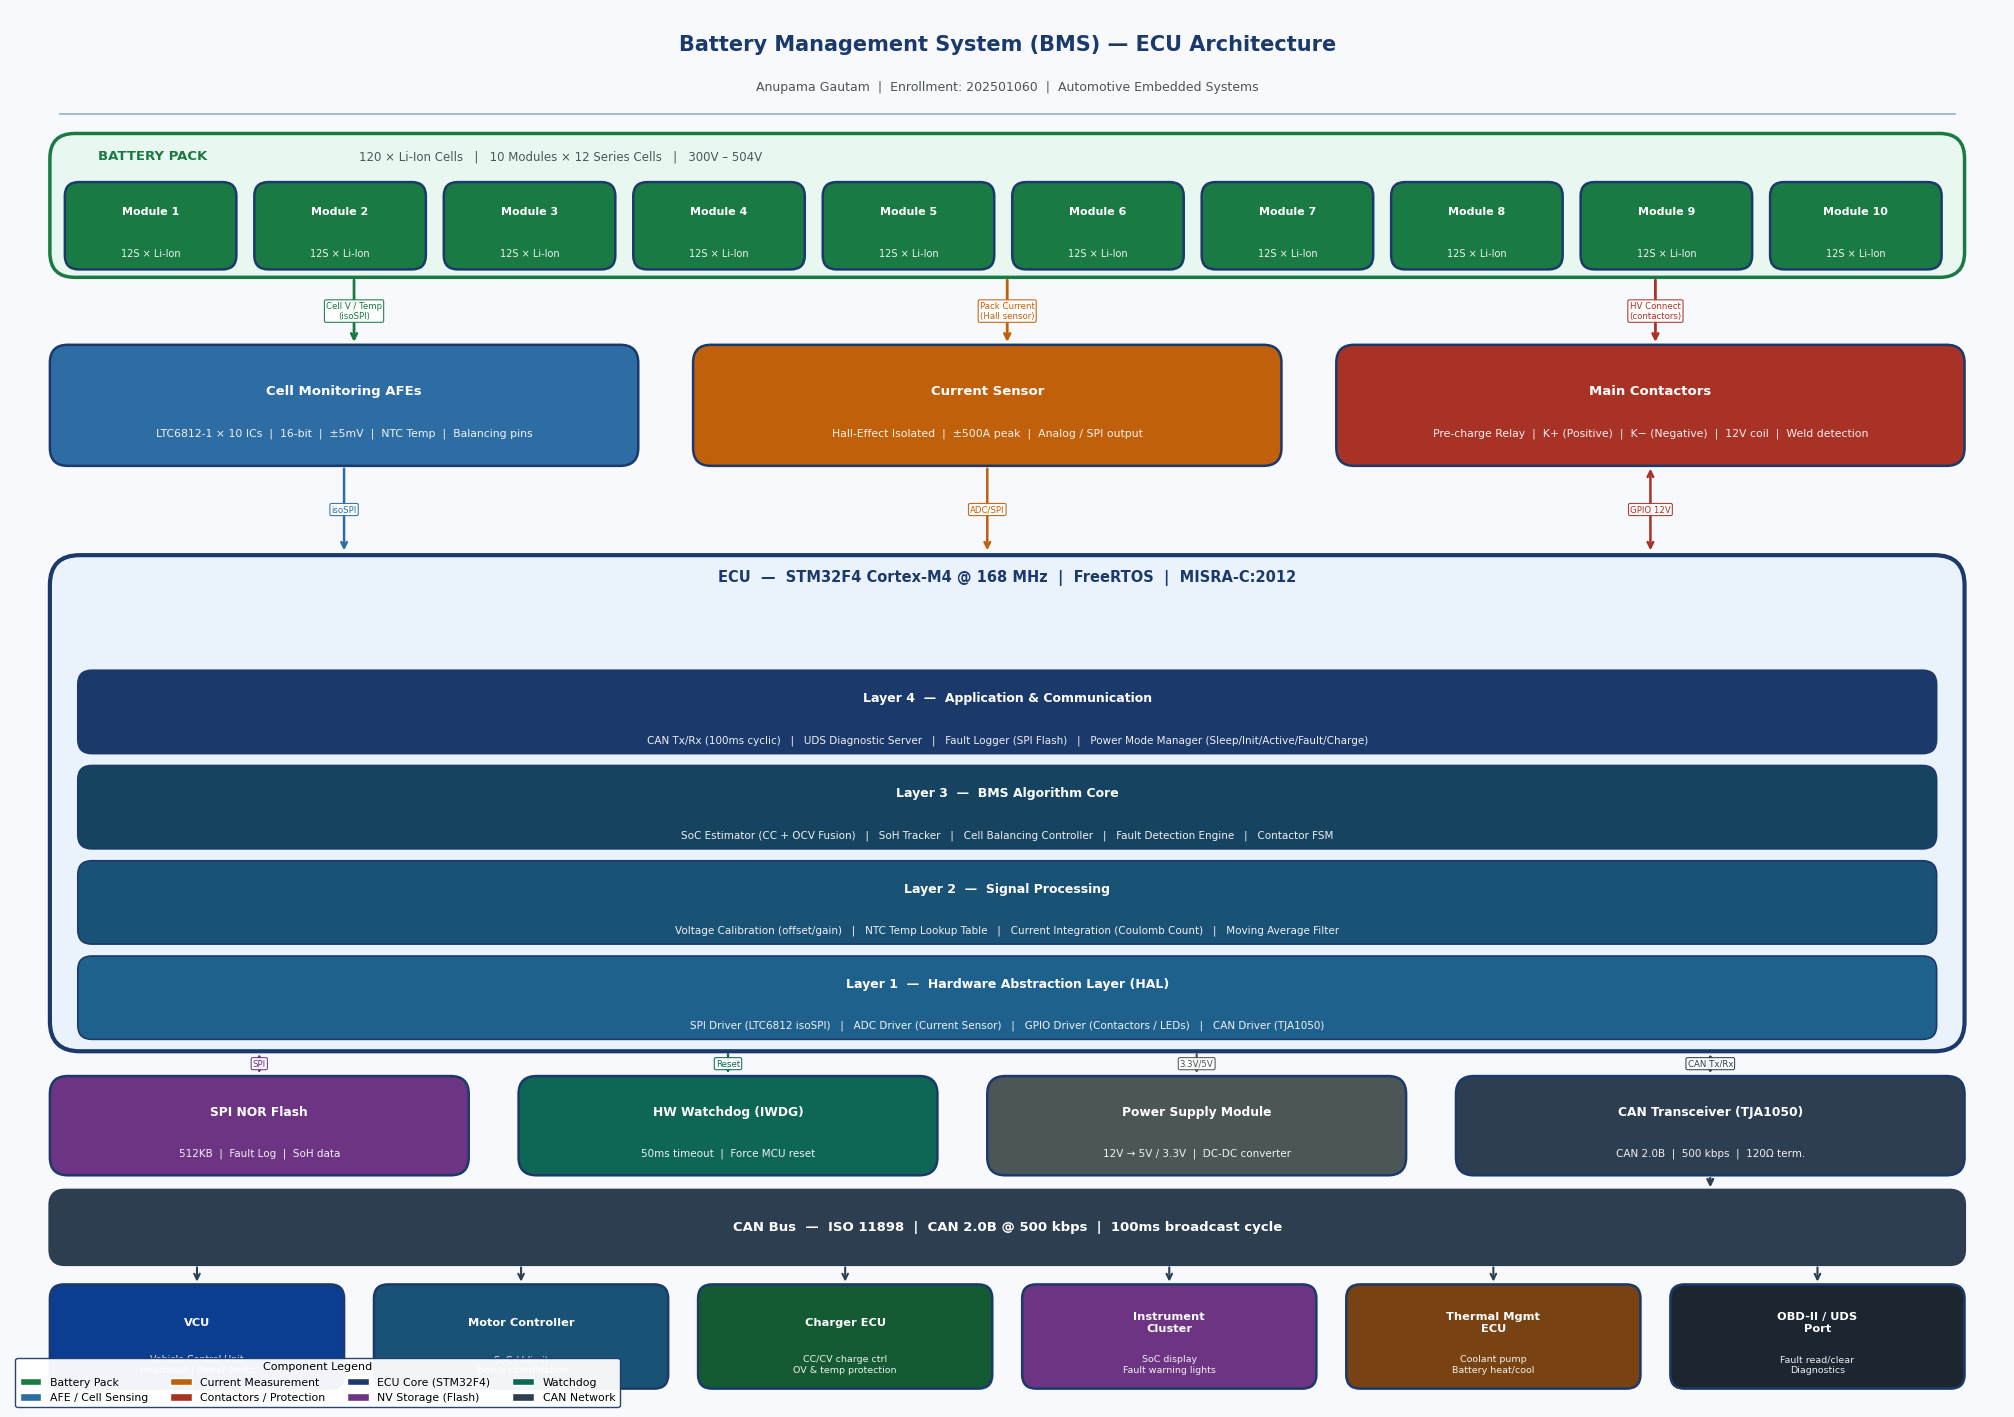

Saved: BMS_Block_Diagram_v2.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_xlim(0, 20)
ax.set_ylim(0, 14)
ax.axis('off')
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

# ── Colors ────────────────────────────────────────────────────────────────────
NAVY    = '#1B3A6B'
BLUE    = '#2E6DA4'
LBLUE   = '#EAF2FB'
GREEN   = '#1A7A43'
LGREEN  = '#E8F8F0'
ORANGE  = '#C0600A'
LORANGE = '#FEF0E6'
RED     = '#A93226'
LRED    = '#FDEDEC'
PURPLE  = '#6C3483'
LPURP   = '#F4ECF7'
GRAY    = '#4D5656'
LGRAY   = '#F0F3F4'
TEAL    = '#0E6655'
LTEAL   = '#E8F6F3'
WHITE   = '#FFFFFF'
DGRAY   = '#2C3E50'

# ── Helper: rounded box ───────────────────────────────────────────────────────
def box(x, y, w, h, title, sub='', fc=BLUE, tc=WHITE, tfc=None,
        border=NAVY, fs=9, sfs=7.5, lw=1.8, radius=0.18):
    patch = FancyBboxPatch((x, y), w, h,
                            boxstyle=f"round,pad=0.0,rounding_size={radius}",
                            linewidth=lw, edgecolor=border, facecolor=fc, zorder=3)
    ax.add_patch(patch)
    # title bar
    if tfc:
        tbar = FancyBboxPatch((x, y+h-0.42), w, 0.42,
                               boxstyle=f"round,pad=0.0,rounding_size={radius}",
                               linewidth=0, facecolor=tfc, zorder=4)
        ax.add_patch(tbar)
    cy = y + h/2 + (0.14 if sub else 0)
    ax.text(x+w/2, cy, title, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=tc, zorder=5,
            multialignment='center')
    if sub:
        ax.text(x+w/2, y+h/2 - 0.28, sub, ha='center', va='center',
                fontsize=sfs, color=tc, zorder=5, multialignment='center',
                alpha=0.92)

# ── Helper: arrow ─────────────────────────────────────────────────────────────
def arr(x1,y1,x2,y2, label='', col=NAVY, lw=1.6, bi=False, rad=0.0,
        lstyle='solid'):
    style = '<->' if bi else '->'
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle=style, color=col, lw=lw,
                                linestyle=lstyle,
                                connectionstyle=f'arc3,rad={rad}'),
                zorder=6)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my, label, fontsize=6.2, color=col, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec=col,
                          alpha=0.92, lw=0.8), zorder=7)

# ── Helper: horizontal bus line ───────────────────────────────────────────────
def hline(x1, x2, y, col=NAVY, lw=2.2):
    ax.plot([x1,x2],[y,y], color=col, lw=lw, zorder=5, solid_capstyle='round')

def vline(x, y1, y2, col=NAVY, lw=1.6):
    ax.plot([x,x],[y1,y2], color=col, lw=lw, zorder=5, solid_capstyle='round')

# ════════════════════════════════════════════════════════════════════════════════
# TITLE
# ════════════════════════════════════════════════════════════════════════════════
ax.text(10, 13.65, 'Battery Management System (BMS) — ECU Architecture',
        ha='center', va='center', fontsize=15, fontweight='bold', color=NAVY,
        zorder=10)
ax.text(10, 13.22, 'Anupama Gautam  |  Enrollment: 202501060  |  Automotive Embedded Systems',
        ha='center', va='center', fontsize=9, color=GRAY, zorder=10)
ax.plot([0.5, 19.5], [12.95, 12.95], color=BLUE, lw=1.2, alpha=0.5)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 1 — BATTERY PACK  (y: 11.4 – 12.7)
# ════════════════════════════════════════════════════════════════════════════════
# Outer container
bp = FancyBboxPatch((0.4, 11.3), 19.2, 1.45,
                     boxstyle="round,pad=0.0,rounding_size=0.25",
                     linewidth=2.5, edgecolor=GREEN, facecolor=LGREEN, zorder=2)
ax.add_patch(bp)
ax.text(0.88, 12.52, 'BATTERY PACK', fontsize=9.5, fontweight='bold',
        color=GREEN, va='center', zorder=5)
ax.text(3.5, 12.52, '120 × Li-Ion Cells   |   10 Modules × 12 Series Cells   |   300V – 504V',
        fontsize=8.5, color=GRAY, va='center', zorder=5)

# 10 module cells — evenly spaced
for i in range(10):
    mx = 0.55 + i * 1.90
    box(mx, 11.38, 1.72, 0.88,
        f'Module {i+1}', '12S × Li-Ion',
        fc=GREEN, tc=WHITE, fs=8, sfs=7, radius=0.14)

# ════════════════════════════════════════════════════════════════════════════════
# ARROWS: Battery → Hardware row
# ════════════════════════════════════════════════════════════════════════════════
# Three downward arrows from pack to hardware
arr(3.45, 11.3, 3.45, 10.62, 'Cell V / Temp\n(isoSPI)', GREEN, lw=2.0)
arr(10.0, 11.3, 10.0, 10.62, 'Pack Current\n(Hall sensor)', ORANGE, lw=2.0)
arr(16.5, 11.3, 16.5, 10.62, 'HV Connect\n(contactors)', RED, lw=2.0)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 2 — HARDWARE SENSING  (y: 9.4 – 10.6)
# ════════════════════════════════════════════════════════════════════════════════
# AFE ICs
box(0.4, 9.4, 5.9, 1.22,
    'Cell Monitoring AFEs', 'LTC6812-1 × 10 ICs  |  16-bit  |  ±5mV  |  NTC Temp  |  Balancing pins',
    fc=BLUE, tc=WHITE, fs=9.5, sfs=7.8)

# Current Sensor
box(6.85, 9.4, 5.9, 1.22,
    'Current Sensor', 'Hall-Effect Isolated  |  ±500A peak  |  Analog / SPI output',
    fc='#C0600A', tc=WHITE, fs=9.5, sfs=7.8)

# Contactors
box(13.3, 9.4, 6.3, 1.22,
    'Main Contactors', 'Pre-charge Relay  |  K+ (Positive)  |  K− (Negative)  |  12V coil  |  Weld detection',
    fc=RED, tc=WHITE, fs=9.5, sfs=7.8)

# ════════════════════════════════════════════════════════════════════════════════
# ARROWS: Hardware → ECU (HAL layer)
# ════════════════════════════════════════════════════════════════════════════════
arr(3.35, 9.4, 3.35, 8.52,  'isoSPI',  BLUE,   lw=1.8)
arr(9.8,  9.4, 9.8,  8.52,  'ADC/SPI', ORANGE, lw=1.8)
arr(16.45,9.4, 16.45,8.52,  'GPIO 12V', RED,   lw=1.8, bi=True)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 3 — ECU INTERNAL (4 layers)  y: 3.6 – 8.5
# ════════════════════════════════════════════════════════════════════════════════
ECU_X, ECU_Y, ECU_W, ECU_H = 0.4, 3.5, 19.2, 5.0

# ECU outer border
ecu_outer = FancyBboxPatch((ECU_X, ECU_Y), ECU_W, ECU_H,
                             boxstyle="round,pad=0.0,rounding_size=0.3",
                             linewidth=3.0, edgecolor=NAVY, facecolor='#EAF2FB',
                             zorder=2)
ax.add_patch(ecu_outer)

ax.text(ECU_X + ECU_W/2, ECU_Y + ECU_H - 0.22,
        'ECU  —  STM32F4 Cortex-M4 @ 168 MHz  |  FreeRTOS  |  MISRA-C:2012',
        ha='center', va='center', fontsize=10.5, fontweight='bold', color=NAVY, zorder=5)

# Layer dimensions
LX = ECU_X + 0.28
LW = ECU_W - 0.56
LH = 0.84
LGAP = 0.12

layer_data = [
    # (y,       title,                   subtitle,                                                fc)
    (ECU_Y+0.12, 'Layer 1  —  Hardware Abstraction Layer (HAL)',
                  'SPI Driver (LTC6812 isoSPI)   |   ADC Driver (Current Sensor)   |   GPIO Driver (Contactors / LEDs)   |   CAN Driver (TJA1050)',
                  '#1F618D'),
    (ECU_Y+0.12+LH+LGAP, 'Layer 2  —  Signal Processing',
                  'Voltage Calibration (offset/gain)   |   NTC Temp Lookup Table   |   Current Integration (Coulomb Count)   |   Moving Average Filter',
                  '#1A5276'),
    (ECU_Y+0.12+2*(LH+LGAP), 'Layer 3  —  BMS Algorithm Core',
                  'SoC Estimator (CC + OCV Fusion)   |   SoH Tracker   |   Cell Balancing Controller   |   Fault Detection Engine   |   Contactor FSM',
                  '#154360'),
    (ECU_Y+0.12+3*(LH+LGAP), 'Layer 4  —  Application & Communication',
                  'CAN Tx/Rx (100ms cyclic)   |   UDS Diagnostic Server   |   Fault Logger (SPI Flash)   |   Power Mode Manager (Sleep/Init/Active/Fault/Charge)',
                  NAVY),
]

for (ly, ltitle, lsub, lfc) in layer_data:
    box(LX, ly, LW, LH, ltitle, lsub,
        fc=lfc, tc=WHITE, fs=9.0, sfs=7.5, radius=0.14, lw=1.2)

# ════════════════════════════════════════════════════════════════════════════════
# SIDE PERIPHERALS (attached to ECU sides)
# ════════════════════════════════════════════════════════════════════════════════
# -- SPI Flash (right of ECU)
box(0.4, 2.25, 4.2, 1.0,
    'SPI NOR Flash', '512KB  |  Fault Log  |  SoH data',
    fc=PURPLE, tc=WHITE, fs=8.8, sfs=7.5)
arr(2.5, 3.5, 2.5, 3.25, 'SPI', PURPLE, lw=1.6, bi=True)

# -- Watchdog
box(5.1, 2.25, 4.2, 1.0,
    'HW Watchdog (IWDG)', '50ms timeout  |  Force MCU reset',
    fc=TEAL, tc=WHITE, fs=8.8, sfs=7.5)
arr(7.2, 3.5, 7.2, 3.25, 'Reset', TEAL, lw=1.6)

# -- Power Supply
box(9.8, 2.25, 4.2, 1.0,
    'Power Supply Module', '12V → 5V / 3.3V  |  DC-DC converter',
    fc=GRAY, tc=WHITE, fs=8.8, sfs=7.5)
arr(11.9, 3.5, 11.9, 3.25, '3.3V/5V', GRAY, lw=1.6)

# -- CAN Transceiver
box(14.5, 2.25, 5.1, 1.0,
    'CAN Transceiver (TJA1050)', 'CAN 2.0B  |  500 kbps  |  120Ω term.',
    fc=DGRAY, tc=WHITE, fs=8.8, sfs=7.5)
arr(17.05, 3.5, 17.05, 3.25, 'CAN Tx/Rx', DGRAY, lw=1.8, bi=True)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 5 — CAN BUS BACKBONE  (y: 1.4 – 1.95)
# ════════════════════════════════════════════════════════════════════════════════
canbus = FancyBboxPatch((0.4, 1.35), 19.2, 0.75,
                          boxstyle="round,pad=0.0,rounding_size=0.15",
                          linewidth=2.2, edgecolor=DGRAY, facecolor=DGRAY, zorder=3)
ax.add_patch(canbus)
ax.text(10, 1.725, 'CAN Bus  —  ISO 11898  |  CAN 2.0B @ 500 kbps  |  100ms broadcast cycle',
        ha='center', va='center', fontsize=9.5, fontweight='bold', color=WHITE, zorder=5)

# Arrow from CAN Transceiver → CAN bus
arr(17.05, 2.25, 17.05, 2.1, '', DGRAY, lw=1.8)

# ════════════════════════════════════════════════════════════════════════════════
# ROW 6 — EXTERNAL ECUs  (y: 0.1 – 1.15)
# ════════════════════════════════════════════════════════════════════════════════
ext = [
    (0.40,  '#0B3D91', 'VCU',              'Vehicle Control Unit\nHeartbeat | Power limits'),
    (3.65,  '#1A5276', 'Motor Controller', 'SoC / I-limit\nTorque coordination'),
    (6.90,  '#145A32', 'Charger ECU',      'CC/CV charge ctrl\nOV & temp protection'),
    (10.15, '#6C3483', 'Instrument\nCluster','SoC display\nFault warning lights'),
    (13.40, '#784212', 'Thermal Mgmt\nECU','Coolant pump\nBattery heat/cool'),
    (16.65, '#1B2631', 'OBD-II / UDS\nPort','Fault read/clear\nDiagnostics'),
]

EW = 2.95
for (ex, efc, etitle, esub) in ext:
    box(ex, 0.1, EW, 1.05, etitle, esub,
        fc=efc, tc=WHITE, fs=8.2, sfs=6.8, radius=0.14)

# Vertical drops from CAN bus → each external ECU
for (ex, *_) in ext:
    cx = ex + EW/2
    arr(cx, 1.35, cx, 1.15, '', DGRAY, lw=1.5)

# ════════════════════════════════════════════════════════════════════════════════
# LEGEND
# ════════════════════════════════════════════════════════════════════════════════
legend_items = [
    mpatches.Patch(facecolor=GREEN,  edgecolor='white', label='Battery Pack'),
    mpatches.Patch(facecolor=BLUE,   edgecolor='white', label='AFE / Cell Sensing'),
    mpatches.Patch(facecolor=ORANGE, edgecolor='white', label='Current Measurement'),
    mpatches.Patch(facecolor=RED,    edgecolor='white', label='Contactors / Protection'),
    mpatches.Patch(facecolor=NAVY,   edgecolor='white', label='ECU Core (STM32F4)'),
    mpatches.Patch(facecolor=PURPLE, edgecolor='white', label='NV Storage (Flash)'),
    mpatches.Patch(facecolor=TEAL,   edgecolor='white', label='Watchdog'),
    mpatches.Patch(facecolor=DGRAY,  edgecolor='white', label='CAN Network'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=7.8,
          framealpha=0.95, edgecolor=NAVY, ncol=4,
          bbox_to_anchor=(0.0, -0.01),
          title='Component Legend', title_fontsize=8)

plt.tight_layout(pad=0.2)
plt.savefig('BMS_Block_Diagram_v2.png', dpi=220, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: BMS_Block_Diagram_v2.png")


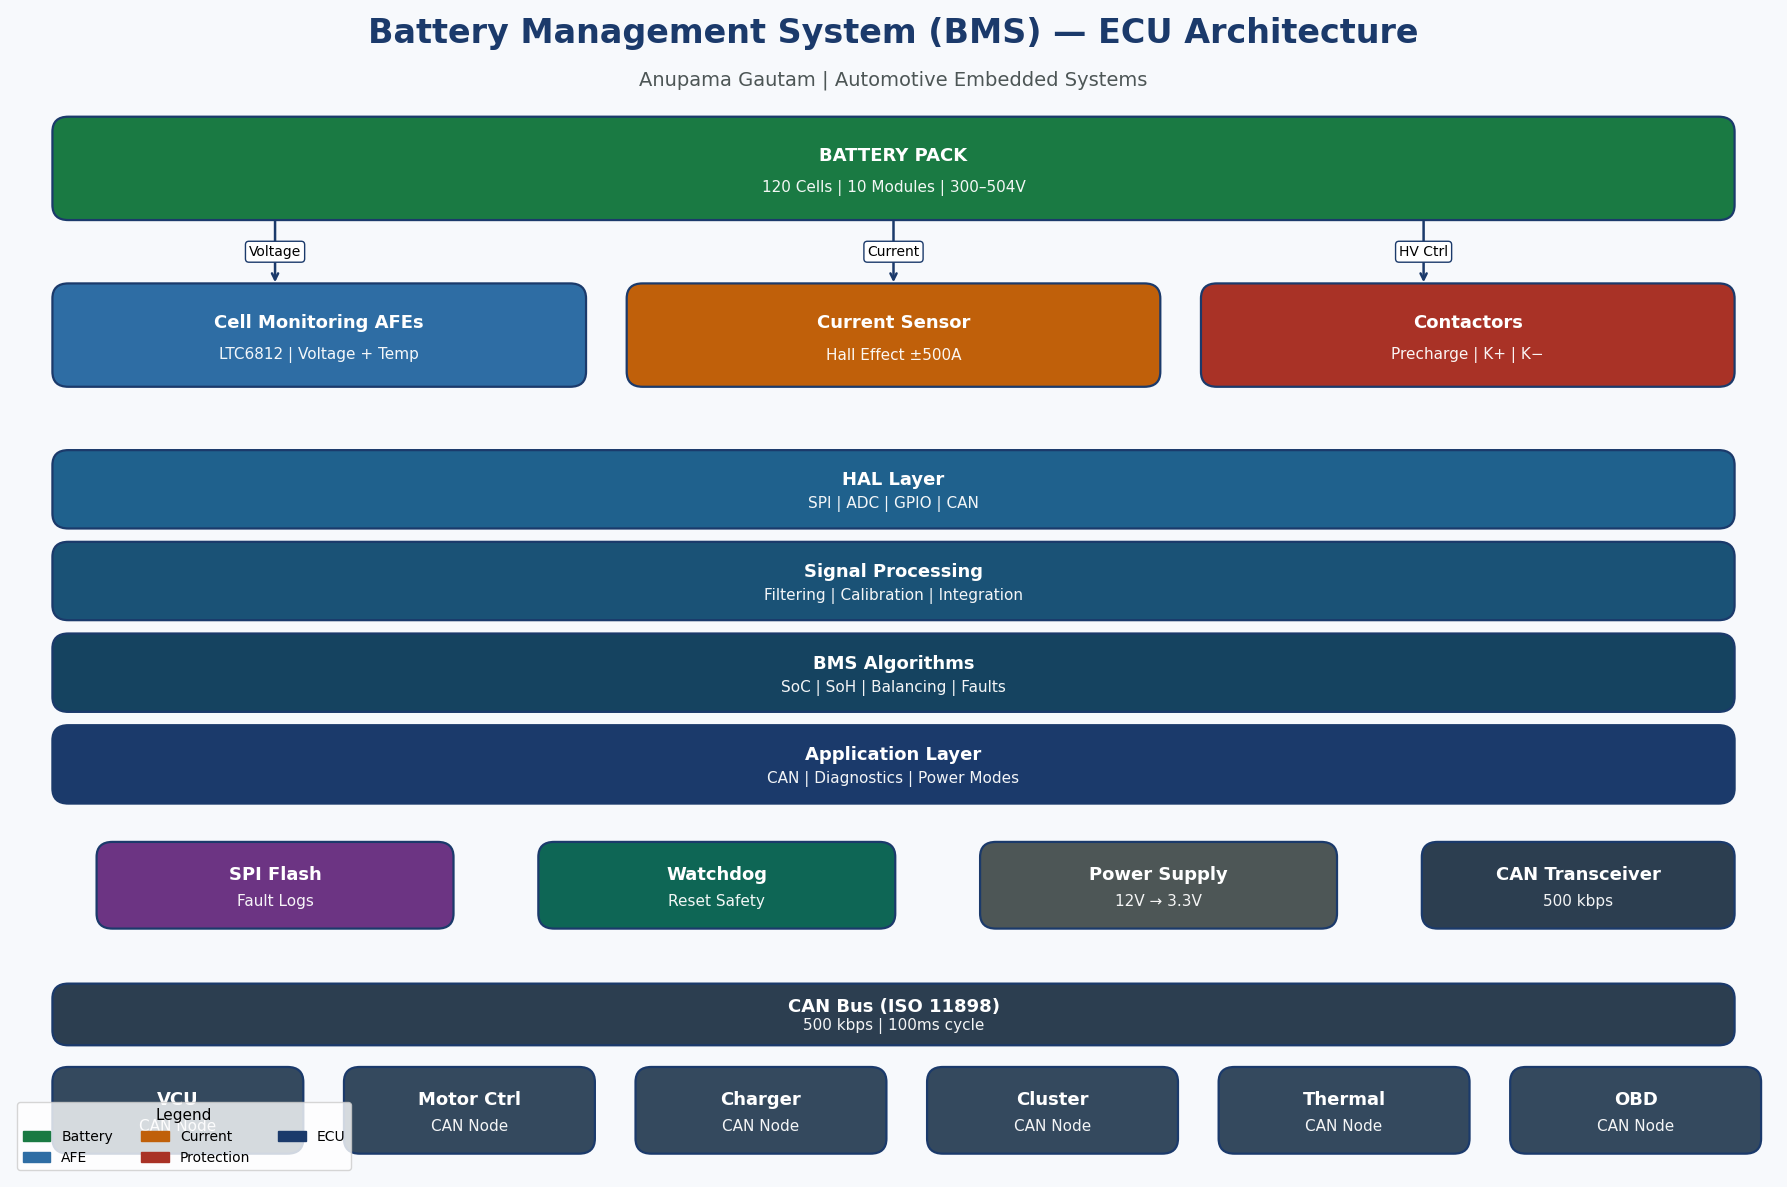

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ─────────────────────────────────────────────────────────────
# GLOBAL FONT SYSTEM (Publication Quality)
# ─────────────────────────────────────────────────────────────
TITLE_FS   = 24
SUBTITLE_FS= 14
SECTION_FS = 13
BODY_FS    = 11
SMALL_FS   = 10
LABEL_FS   = 10

plt.rcParams.update({
    "font.size": BODY_FS,
    "font.family": "DejaVu Sans"
})

# ─────────────────────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 20)
ax.set_ylim(0, 14)
ax.axis('off')

fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

# ─────────────────────────────────────────────────────────────
# COLORS
# ─────────────────────────────────────────────────────────────
NAVY    = '#1B3A6B'
BLUE    = '#2E6DA4'
GREEN   = '#1A7A43'
LGREEN  = '#E8F8F0'
ORANGE  = '#C0600A'
RED     = '#A93226'
PURPLE  = '#6C3483'
GRAY    = '#4D5656'
DGRAY   = '#2C3E50'
WHITE   = '#FFFFFF'
TEAL    = '#0E6655'

# ─────────────────────────────────────────────────────────────
# BOX FUNCTION (Improved Typography)
# ─────────────────────────────────────────────────────────────
def box(x, y, w, h, title, sub='',
        fc=BLUE, tc=WHITE,
        fs=SECTION_FS, sfs=BODY_FS):

    patch = FancyBboxPatch((x, y), w, h,
                           boxstyle="round,pad=0.02,rounding_size=0.18",
                           linewidth=1.6, edgecolor=NAVY,
                           facecolor=fc)
    ax.add_patch(patch)

    ax.text(x + w/2, y + h*0.62,
            title, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=tc)

    if sub:
        ax.text(x + w/2, y + h*0.30,
                sub, ha='center', va='center',
                fontsize=sfs, color=tc, alpha=0.95)

# ─────────────────────────────────────────────────────────────
# ARROW FUNCTION (Readable Labels)
# ─────────────────────────────────────────────────────────────
def arr(x1, y1, x2, y2, label='', col=NAVY, bi=False):

    style = '<->' if bi else '->'

    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle=style,
                                color=col, lw=1.8))

    if label:
        ax.text((x1+x2)/2, (y1+y2)/2,
                label, fontsize=LABEL_FS,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.25',
                          fc='white', ec=col, lw=1))

# ─────────────────────────────────────────────────────────────
# TITLE
# ─────────────────────────────────────────────────────────────
ax.text(10, 13.6,
        'Battery Management System (BMS) — ECU Architecture',
        ha='center', fontsize=TITLE_FS,
        fontweight='bold', color=NAVY)

ax.text(10, 13.1,
        'Anupama Gautam | Automotive Embedded Systems',
        ha='center', fontsize=SUBTITLE_FS,
        color=GRAY)

# ─────────────────────────────────────────────────────────────
# BATTERY PACK
# ─────────────────────────────────────────────────────────────
box(0.5, 11.5, 19, 1.2,
    'BATTERY PACK',
    '120 Cells | 10 Modules | 300–504V',
    fc=GREEN)

# ─────────────────────────────────────────────────────────────
# HARDWARE
# ─────────────────────────────────────────────────────────────
box(0.5, 9.5, 6, 1.2,
    'Cell Monitoring AFEs',
    'LTC6812 | Voltage + Temp',
    fc=BLUE)

box(7, 9.5, 6, 1.2,
    'Current Sensor',
    'Hall Effect ±500A',
    fc=ORANGE)

box(13.5, 9.5, 6, 1.2,
    'Contactors',
    'Precharge | K+ | K−',
    fc=RED)

# ─────────────────────────────────────────────────────────────
# ECU LAYERS
# ─────────────────────────────────────────────────────────────
box(0.5, 7.8, 19, 0.9,
    'HAL Layer',
    'SPI | ADC | GPIO | CAN',
    fc='#1F618D')

box(0.5, 6.7, 19, 0.9,
    'Signal Processing',
    'Filtering | Calibration | Integration',
    fc='#1A5276')

box(0.5, 5.6, 19, 0.9,
    'BMS Algorithms',
    'SoC | SoH | Balancing | Faults',
    fc='#154360')

box(0.5, 4.5, 19, 0.9,
    'Application Layer',
    'CAN | Diagnostics | Power Modes',
    fc=NAVY)

# ─────────────────────────────────────────────────────────────
# SIDE COMPONENTS
# ─────────────────────────────────────────────────────────────
box(1, 3, 4, 1, 'SPI Flash', 'Fault Logs', fc=PURPLE)
box(6, 3, 4, 1, 'Watchdog', 'Reset Safety', fc=TEAL)
box(11, 3, 4, 1, 'Power Supply', '12V → 3.3V', fc=GRAY)
box(16, 3, 3.5, 1, 'CAN Transceiver', '500 kbps', fc=DGRAY)

# ─────────────────────────────────────────────────────────────
# CAN BUS
# ─────────────────────────────────────────────────────────────
box(0.5, 1.6, 19, 0.7,
    'CAN Bus (ISO 11898)',
    '500 kbps | 100ms cycle',
    fc=DGRAY)

# ─────────────────────────────────────────────────────────────
# EXTERNAL ECUs
# ─────────────────────────────────────────────────────────────
names = ['VCU', 'Motor Ctrl', 'Charger', 'Cluster', 'Thermal', 'OBD']
xpos = [0.5, 3.8, 7.1, 10.4, 13.7, 17]

for i, name in enumerate(names):
    box(xpos[i], 0.3, 2.8, 1,
        name, 'CAN Node', fc='#34495E')

# ─────────────────────────────────────────────────────────────
# CONNECTIONS
# ─────────────────────────────────────────────────────────────
arr(3, 11.5, 3, 10.7, 'Voltage')
arr(10, 11.5, 10, 10.7, 'Current')
arr(16, 11.5, 16, 10.7, 'HV Ctrl')

# ─────────────────────────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=GREEN, label='Battery'),
    mpatches.Patch(color=BLUE, label='AFE'),
    mpatches.Patch(color=ORANGE, label='Current'),
    mpatches.Patch(color=RED, label='Protection'),
    mpatches.Patch(color=NAVY, label='ECU'),
]

ax.legend(handles=legend_items,
          loc='lower left',
          fontsize=SMALL_FS,
          title='Legend',
          title_fontsize=BODY_FS,
          ncol=3)

# ─────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('BMS_Diagram_Refactored.png',
            dpi=300, bbox_inches='tight')
plt.show()

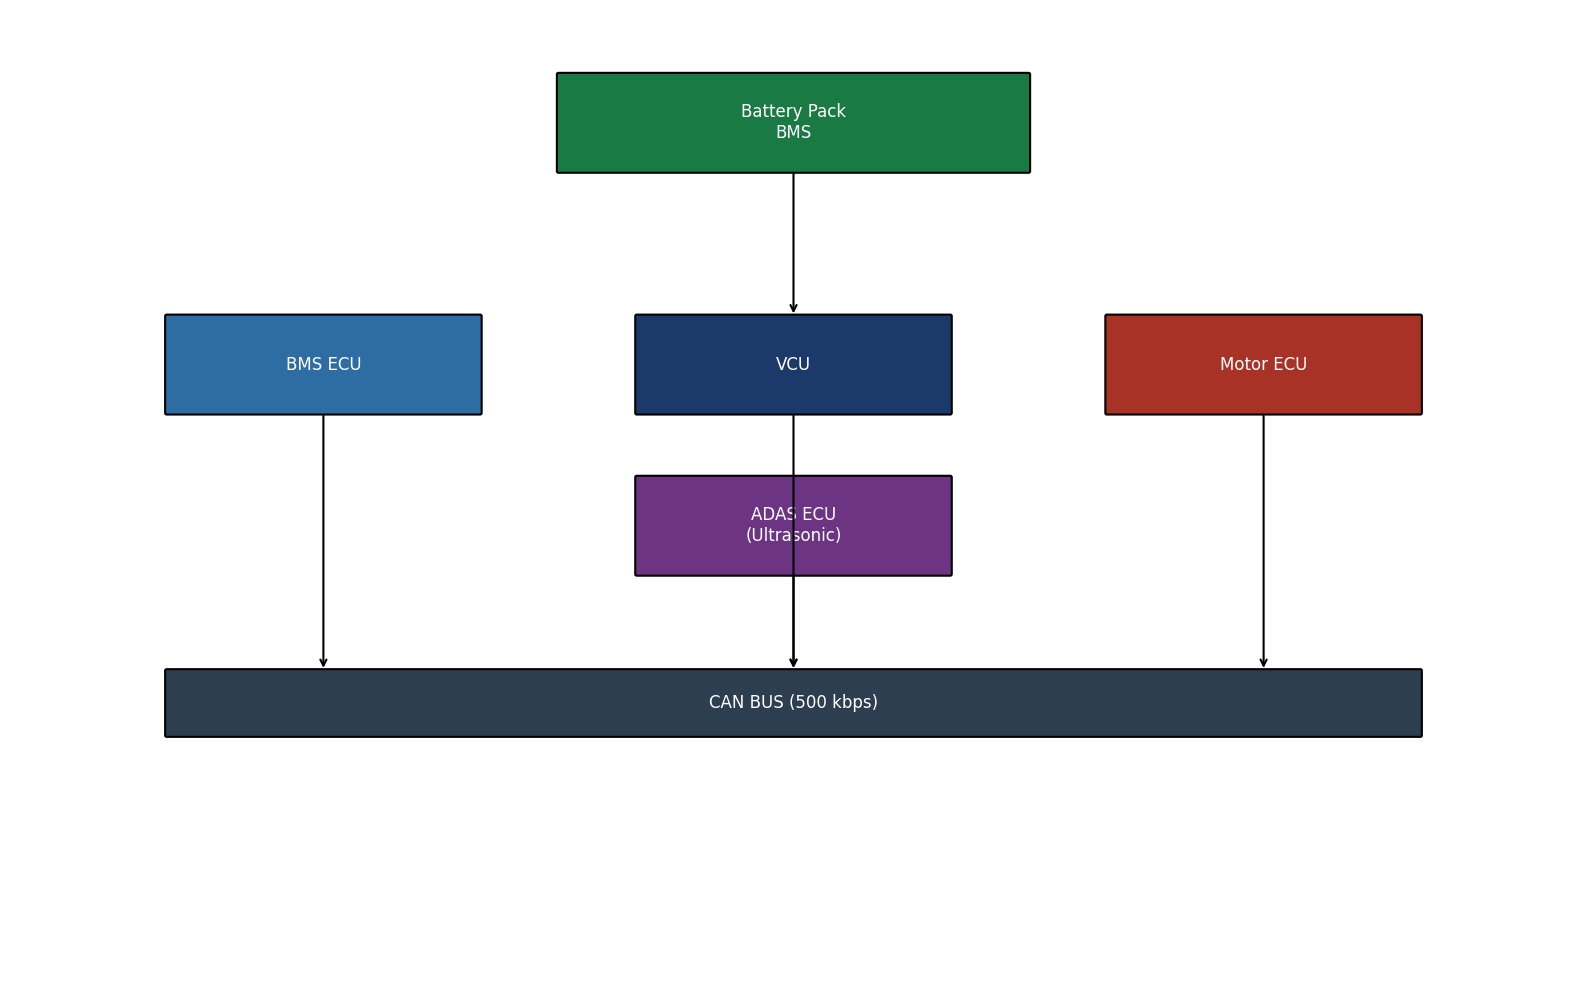

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ─────────────────────────────────────────
# FONT SYSTEM
# ─────────────────────────────────────────
TITLE = 20
SECTION = 12
TEXT = 10

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 20)
ax.set_ylim(0, 12)
ax.axis('off')

# ─────────────────────────────────────────
# BOX FUNCTION
# ─────────────────────────────────────────
def box(x, y, w, h, text, color):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.02",
                          fc=color, ec='black', lw=1.5)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text,
            ha='center', va='center',
            fontsize=SECTION, color='white')

# ─────────────────────────────────────────
# ARROW FUNCTION
# ─────────────────────────────────────────
def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', lw=1.5))

# ─────────────────────────────────────────
# TOP: BATTERY
# ─────────────────────────────────────────
box(7, 10, 6, 1.2, "Battery Pack\nBMS", "#1A7A43")

# ─────────────────────────────────────────
# MIDDLE: ECUs
# ─────────────────────────────────────────
box(2, 7, 4, 1.2, "BMS ECU", "#2E6DA4")
box(8, 7, 4, 1.2, "VCU", "#1B3A6B")
box(14, 7, 4, 1.2, "Motor ECU", "#A93226")

# ─────────────────────────────────────────
# ADAS
# ─────────────────────────────────────────
box(8, 5, 4, 1.2, "ADAS ECU\n(Ultrasonic)", "#6C3483")

# ─────────────────────────────────────────
# CAN BUS
# ─────────────────────────────────────────
box(2, 3, 16, 0.8, "CAN BUS (500 kbps)", "#2C3E50")

# ─────────────────────────────────────────
# CONNECTIONS
# ─────────────────────────────────────────
arrow(10,10,10,8.2)
arrow(4,7,4,3.8)
arrow(10,7,10,3.8)
arrow(16,7,16,3.8)
arrow(10,5,10,3.8)

# ─────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────
plt.tight_layout()
plt.savefig("EV_System_Diagram.png", dpi=300)
plt.show()

In [ ]:
# @title List available models
from google.colab import ai

ai.list_models()

['google/gemini-2.0-flash',
 'google/gemini-2.0-flash-lite',
 'google/gemini-2.5-flash',
 'google/gemini-2.5-flash-lite',
 'google/gemini-2.5-pro',
 'google/gemma-3-12b',
 'google/gemma-3-1b',
 'google/gemma-3-27b',
 'google/gemma-3-4b']

Choosing a Model
The model names give you a hint about their capabilities and intended use:

Pro: These are the most capable models, ideal for complex reasoning, creative tasks, and detailed analysis.

Flash: These models are optimized for high speed and efficiency, making them great for summarization, chat applications, and tasks requiring rapid responses.

Gemma: These are lightweight, open-weight models suitable for a variety of text generation tasks and are great for experimentation.

In [ ]:
# @title Simple batch generation example
# Only text-to-text input/output is supported
from google.colab import ai

response = ai.generate_text("What is the capital of France?")
print(response)

The capital of France is **Paris**.



In [ ]:
# @title Choose a different model
from google.colab import ai

response = ai.generate_text("What is the capital of England", model_name='google/gemini-2.0-flash-lite')
print(response)

The capital of England is **London**.



For longer text generations, you can stream the response. This displays the output token by token as it's generated, rather than waiting for the entire response to complete. This provides a more interactive and responsive experience. To enable this, simply set stream=True.

In [ ]:
# @title Simple streaming example
from google.colab import ai

stream = ai.generate_text("Tell me a short story.", stream=True)
for text in stream:
  print(text, end='')

The lighthouse keeper, Silas, was a man of routine. Every night, for fifty years, he'd lit the lamp, a beacon against the treacherous rocks that gnawed at the coastline. The sea was his companion, his enemy, and his only confidante. He knew its moods better than his own.

One stormy night, the wind howled like a banshee. The waves crashed against the tower, shaking it to its core. Silas, clinging to the railing, felt a fear he hadn't experienced in decades. This wasn't just a storm; this was a monster.

Suddenly, a small, wooden boat, tossed about like a toy, appeared in the raging sea. He squinted, his heart leaping into his throat. A child. Alone.

Ignoring the raging tempest, Silas raced down the winding stairs, his old bones protesting with every step. He launched his small rescue boat, a fragile craft against the fury of the storm.

Fighting the waves, he reached the child. A girl, no older than seven, clung to the wreckage, her face white with terror. With a strength born of desp

In [ ]:
#@title Text formatting setup
#code is not necessary for colab.ai, but is useful in fomatting text chunks
import sys

class LineWrapper:
    def __init__(self, max_length=80):
        self.max_length = max_length
        self.current_line_length = 0

    def print(self, text_chunk):
        i = 0
        n = len(text_chunk)
        while i < n:
            start_index = i
            while i < n and text_chunk[i] not in ' \n': # Find end of word
                i += 1
            current_word = text_chunk[start_index:i]

            delimiter = ""
            if i < n: # If not end of chunk, we found a delimiter
                delimiter = text_chunk[i]
                i += 1 # Consume delimiter

            if current_word:
                needs_leading_space = (self.current_line_length > 0)

                # Case 1: Word itself is too long for a line (must be broken)
                if len(current_word) > self.max_length:
                    if needs_leading_space: # Newline if current line has content
                        sys.stdout.write('\n')
                        self.current_line_length = 0
                    for char_val in current_word: # Break the long word
                        if self.current_line_length >= self.max_length:
                            sys.stdout.write('\n')
                            self.current_line_length = 0
                        sys.stdout.write(char_val)
                        self.current_line_length += 1
                # Case 2: Word doesn't fit on current line (print on new line)
                elif self.current_line_length + (1 if needs_leading_space else 0) + len(current_word) > self.max_length:
                    sys.stdout.write('\n')
                    sys.stdout.write(current_word)
                    self.current_line_length = len(current_word)
                # Case 3: Word fits on current line
                else:
                    if needs_leading_space:
                        # Define punctuation that should not have a leading space
                        # when they form an entire "word" (token) following another word.
                        no_leading_space_punctuation = {
                            ",", ".", ";", ":", "!", "?",        # Standard sentence punctuation
                            ")", "]", "}",                     # Closing brackets
                            "'s", "'S", "'re", "'RE", "'ve", "'VE", # Common contractions
                            "'m", "'M", "'ll", "'LL", "'d", "'D",
                            "n't", "N'T",
                            "...", "…"                          # Ellipses
                        }
                        if current_word not in no_leading_space_punctuation:
                            sys.stdout.write(' ')
                            self.current_line_length += 1
                    sys.stdout.write(current_word)
                    self.current_line_length += len(current_word)

            if delimiter == '\n':
                sys.stdout.write('\n')
                self.current_line_length = 0
            elif delimiter == ' ':
                # If line is full and a space delimiter arrives, it implies a wrap.
                if self.current_line_length >= self.max_length:
                    sys.stdout.write('\n')
                    self.current_line_length = 0

        sys.stdout.flush()


In [ ]:
# @title Formatted streaming example
from google.colab import ai

wrapper = LineWrapper()
for chunk in ai.generate_text('Give me a long winded description about the evolution of the Roman Empire.', model_name='google/gemini-2.0-flash', stream=True):
  wrapper.print(chunk)

Alright, settle in, because the Roman Empire’s evolution wasn't a tidy, linear
process. It was a centuries-long, tumultuous transformation, marked by
breathtaking innovation, brutal power struggles, and a slow, creeping societal
decay. We're talking about a journey from a humble city-state in the Italian
peninsula to a sprawling, multifaceted empire that left an indelible mark on
law, language, architecture, governance, and even our very understanding of the
world.

It all began, as legend would have it, with Romulus and Remus, twin brothers
raised by a she-wolf, who founded the city of Rome in 753 BCE. Now, that’s just
a legend, but it serves to highlight the foundational spirit of Rome: ambition,
strength, and a certain ruthlessness. Initially, Rome was ruled by a monarchy, a
system eventually deemed unsatisfactory by the powerful patrician class. This
led to the **Roman Republic**, established around 509 BCE, a watershed moment
that would define the early character of Rome.

The Rep